In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
from FinMind.data import DataLoader
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK TC",
]
plt.rcParams["axes.unicode_minus"] = False
api = DataLoader()
# 若有帳號可登入解除頻率限制：
# api.login(user_id='你的帳號', password='你的密碼')

In [ ]:
def analyze_stock_daily(ticker: str, years: int = 3):
    """
    分析台股股票的日報酬分布與每週漲跌特性。
    
    Parameters:
        ticker (str): 股票代號，例如 '3135'
        years (int): 回溯年數，預設為 3 年
    """
    today = datetime.today()
    start_date = (today - relativedelta(years=years)).strftime("%Y-%m-%d")
    end_date = today.strftime("%Y-%m-%d")
    print('start date', start_date)
    print('end date', end_date)

    # 取得資料
    df = api.taiwan_stock_daily(
        stock_id=ticker,
        start_date=start_date,
        end_date=end_date
    )

    df.set_index('date', inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df.rename(columns={
        'max': 'High',
        'min': 'Low',
        'open': 'Open',
        'close': 'Close',
        'Trading_Volume': 'Volume'
    })

    # 新增星期幾欄位（0=週一, 4=週五）
    df['date_weekday'] = df.index.dayofweek

    # 計算日報酬率
    df['netChangeRatio'] = df['Close'].pct_change() * 100

    # 日報酬分布直方圖
    df['netChangeRatio'].dropna().hist(bins=80)
    plt.xlabel('Daily Return (%)')
    plt.ylabel('Count')
    plt.title(f'{ticker} Daily Return Distribution')
    plt.show()

    # qcut 分成 10 組
    cats_q = pd.qcut(df['netChangeRatio'].dropna(), 10)
    print("=" * 50)
    print(f"📊 [{ticker}] 日報酬率十等分區間分布")
    print("  （將所有交易日依報酬率高低平均切成 10 組，數字為落在該區間的天數）")
    print("-" * 50)
    print(cats_q.value_counts().sort_index().to_string())
    print()

    # 離散化（±10% 限制）
    bins = [-np.inf, -7, -5, -3, 0, 3, 5, 7, np.inf]
    bin_labels = ['重挫(< -7%)', '大跌(-7%~-5%)', '中跌(-5%~-3%)', '小跌(-3%~0%)',
                  '小漲(0%~3%)', '中漲(3%~5%)', '大漲(5%~7%)', '急漲(> 7%)']
    cats = pd.cut(df['netChangeRatio'], bins=bins, labels=bin_labels)
    print("=" * 50)
    print(f"📊 [{ticker}] 日報酬率區間分布（依漲跌幅分 8 級）")
    print("  （台股漲跌幅限制 ±10%，依幅度大小分級統計天數）")
    print("-" * 50)
    print(cats.value_counts().sort_index().to_string())
    print()

    # One-hot encoding 並合併
    change_ratio_dummies = pd.get_dummies(cats, prefix='cr_dummies')
    df_concat = pd.concat([df, change_ratio_dummies], axis=1)

    # 漲跌標記
    df['positive'] = np.where(df['netChangeRatio'] > 0, 1, 0)

    # 交叉比對表
    xt = pd.crosstab(df['date_weekday'], df['positive'])

    # 視覺化：漲跌跟星期幾的關係
    xt_pct = xt.div(xt.sum(axis=1).astype(float), axis=0)
    xt_pct.plot(kind='bar', stacked=True)
    plt.xticks(ticks=range(5), labels=['週一', '週二', '週三', '週四', '週五'], rotation=0)
    plt.xlabel('星期幾')
    plt.ylabel('比例')
    plt.title(f'{ticker} 每週各天漲跌比例')
    plt.legend(['下跌', '上漲'])
    plt.show()

    # 各天平均上漲機率
    pivot = df.pivot_table(['positive'], index=['date_weekday'])
    pivot.index = ['週一', '週二', '週三', '週四', '週五']
    print(pivot)

2026-05-27 15:19:07.921 | INFO     | FinMind.data.finmind_api:get_data:171 - download Dataset.TaiwanStockPrice, data_id: 00631L


start date 2025-05-27
end date 2026-05-27


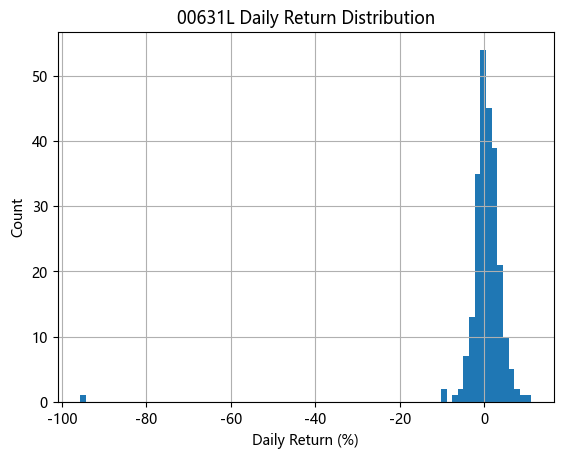

📊 [00631L] 日報酬率十等分區間分布
  （將所有交易日依報酬率高低平均切成 10 組，數字為落在該區間的天數）
--------------------------------------------------
netChangeRatio
(-95.655, -2.357]    24
(-2.357, -1.398]     24
(-1.398, -0.606]     24
(-0.606, 0.00461]    24
(0.00461, 0.539]     24
(0.539, 1.389]       23
(1.389, 1.892]       24
(1.892, 2.582]       24
(2.582, 3.867]       24
(3.867, 11.041]      24

📊 [00631L] 日報酬率區間分布（依漲跌幅分 8 級）
  （台股漲跌幅限制 ±10%，依幅度大小分級統計天數）
--------------------------------------------------
netChangeRatio
重挫(< -7%)        3
大跌(-7%~-5%)      3
中跌(-5%~-3%)     12
小跌(-3%~0%)      78
小漲(0%~3%)      102
中漲(3%~5%)       26
大漲(5%~7%)       10
急漲(> 7%)         5



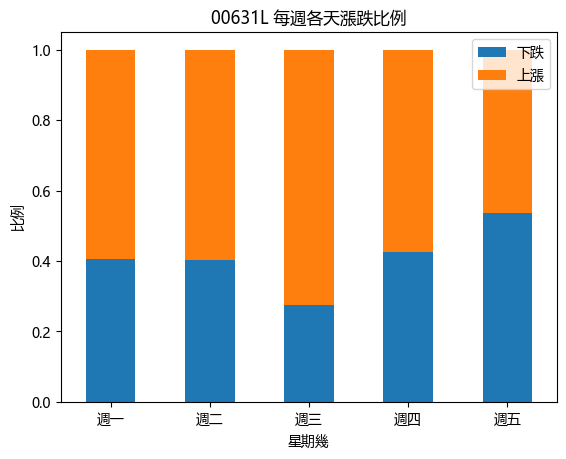

    positive
週一  0.595745
週二  0.596154
週三  0.725490
週四  0.574468
週五  0.465116


In [33]:
analyze_stock_daily('00631L', 1)